# Q6 — Temporal SHAP: Is this SKU experiencing a spike, growth, or stable demand?
Validates `src/xai/temporal_shap.py`.

## 1) Imports and Paths

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import sys

sys.path.insert(0, str(Path('..').resolve() / 'src'))

from xai.temporal_shap import (
    compute_temporal_shap,
    classify_demand_pattern,
    get_top_temporal_drivers,
    generate_temporal_explanation_text,
)

ROOT       = Path('..').resolve()
DATA_DIR   = ROOT / 'data' / 'processed' / 'LGBM_XGB_7_V3'
MODEL_PATH = ROOT / 'artifacts' / 'models' / 'tuned_lgbm_7_v3.joblib'

print('MODEL_PATH:', MODEL_PATH)

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MODEL_PATH: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\models\tuned_lgbm_7_v3.joblib


## 2) Load Model and Test Data

In [2]:
model   = joblib.load(MODEL_PATH)
test_df = pd.read_csv(DATA_DIR / 'test.csv')
test_df['date'] = pd.to_datetime(test_df['date'], errors='coerce')

TARGET    = 'aggregated_sales_7'
DROP_COLS = [TARGET, 'date', 'item_id']
feature_cols = [c for c in test_df.columns if c not in DROP_COLS]

X_test = test_df[feature_cols].copy()
y_test = test_df[TARGET].copy()

# Pick the SKU with the most rows in the test set for a rich time series
sku_counts = test_df['item_id'].value_counts()
target_sku = sku_counts.index[0]
print(f'Chosen SKU: {target_sku}  ({sku_counts[target_sku]} rows in test)')

Chosen SKU: FOODS_1_001  (11 rows in test)


## 3) Compute Temporal SHAP

In [3]:
temporal_df = compute_temporal_shap(
    model     = model,
    X         = X_test,
    dates     = test_df['date'],
    item_ids  = test_df['item_id'],
    sku_id    = target_sku,
)

print(f'Temporal SHAP shape: {temporal_df.shape}')
print(f'Date range: {temporal_df["date"].min()} → {temporal_df["date"].max()}')
temporal_df[['date', 'prediction', 'total_shap', 'sales_lag_7', 'item_mean_train', 'sales_roll_mean_7']].head(10)

[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
Temporal SHAP shape: (11, 34)
Date range: 2016-02-17 00:00:00 → 2016-04-24 00:00:00


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\e

,date,prediction,total_shap,sales_lag_7,item_mean_train,sales_roll_mean_7
0,2016-02-17,4.541914,-9.702062,-3.110442,-3.219208,-1.082107
1,2016-02-24,4.458857,-9.785119,-3.504077,-3.216531,-1.151531
2,2016-03-02,4.395177,-9.848799,-3.813369,-3.123478,-1.298035
3,2016-03-09,4.282185,-9.961791,-4.325108,-2.746446,-1.467116
4,2016-03-16,4.193335,-10.050641,-4.266162,-2.704737,-1.456699
5,2016-03-23,4.608279,-9.635697,-3.237158,-3.359631,-1.095350
6,2016-03-30,5.649954,-8.594022,-2.321192,-3.467071,-0.712126
7,2016-04-06,4.546335,-9.697641,-3.538092,-3.284518,-1.158835
8,2016-04-13,5.790348,-8.453627,-2.012256,-3.529650,-0.657962
9,2016-04-20,4.461720,-9.782255,-3.482329,-3.246609,-1.147709


## 4) Classify Demand Pattern

In [4]:
pattern_info = classify_demand_pattern(temporal_df, target_sku)
for k, v in pattern_info.items():
    print(f'  {k:15s}: {v}')

  sku_id         : FOODS_1_001
  pattern        : stable
  confidence     : 0.893
  mean_pred      : 4.71
  std_pred       : 0.51
  trend_slope    : 0.0716
  cv             : 0.1075


## 5) Top Temporal SHAP Drivers

In [5]:
top_drivers = get_top_temporal_drivers(temporal_df, n=8)
print(top_drivers.to_string(index=False))

               feature  mean_shap  std_shap  temporal_variance
           sales_lag_7  -3.328474  0.681905           0.464995
       item_mean_train  -3.202694  0.250375           0.062688
     sales_roll_mean_7  -1.111620  0.245736           0.060386
        item_std_train  -1.108646  0.212069           0.044973
         snap_relevant  -0.013050  0.128810           0.016592
event_valentines_day_7  -0.025104  0.103678           0.010749
        event_easter_7   0.014973  0.062797           0.003943
weeks_since_first_seen  -0.414138  0.046523           0.002164


## 6) Visualize: Prediction Over Time + Top Feature SHAP Trajectories

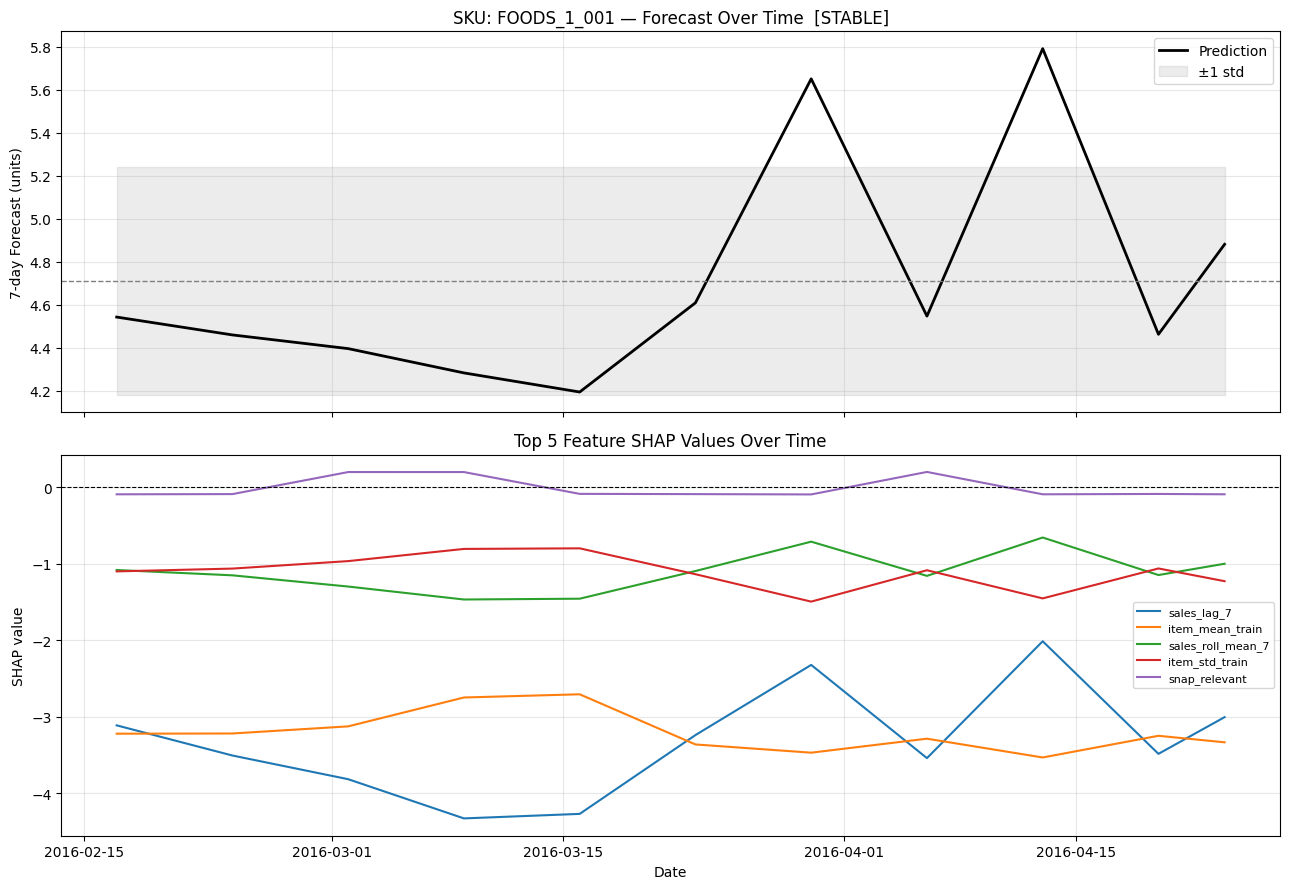

In [6]:
top5_feats = top_drivers.head(5)['feature'].tolist()

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# --- Top: prediction over time ---
axes[0].plot(temporal_df['date'], temporal_df['prediction'], color='black', linewidth=2, label='Prediction')
axes[0].fill_between(
    temporal_df['date'],
    temporal_df['prediction'].mean() - temporal_df['prediction'].std(),
    temporal_df['prediction'].mean() + temporal_df['prediction'].std(),
    alpha=0.15, color='gray', label='±1 std'
)
axes[0].axhline(temporal_df['prediction'].mean(), color='gray', linestyle='--', linewidth=1)
axes[0].set_ylabel('7-day Forecast (units)')
axes[0].set_title(f'SKU: {target_sku} — Forecast Over Time  [{pattern_info["pattern"].upper()}]')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Bottom: top feature SHAP over time ---
for feat in top5_feats:
    if feat in temporal_df.columns:
        axes[1].plot(temporal_df['date'], temporal_df[feat], label=feat, linewidth=1.5)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_ylabel('SHAP value')
axes[1].set_title('Top 5 Feature SHAP Values Over Time')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.xlabel('Date')
plt.tight_layout()
plt.show()

## 7) SHAP Heatmap Over Time

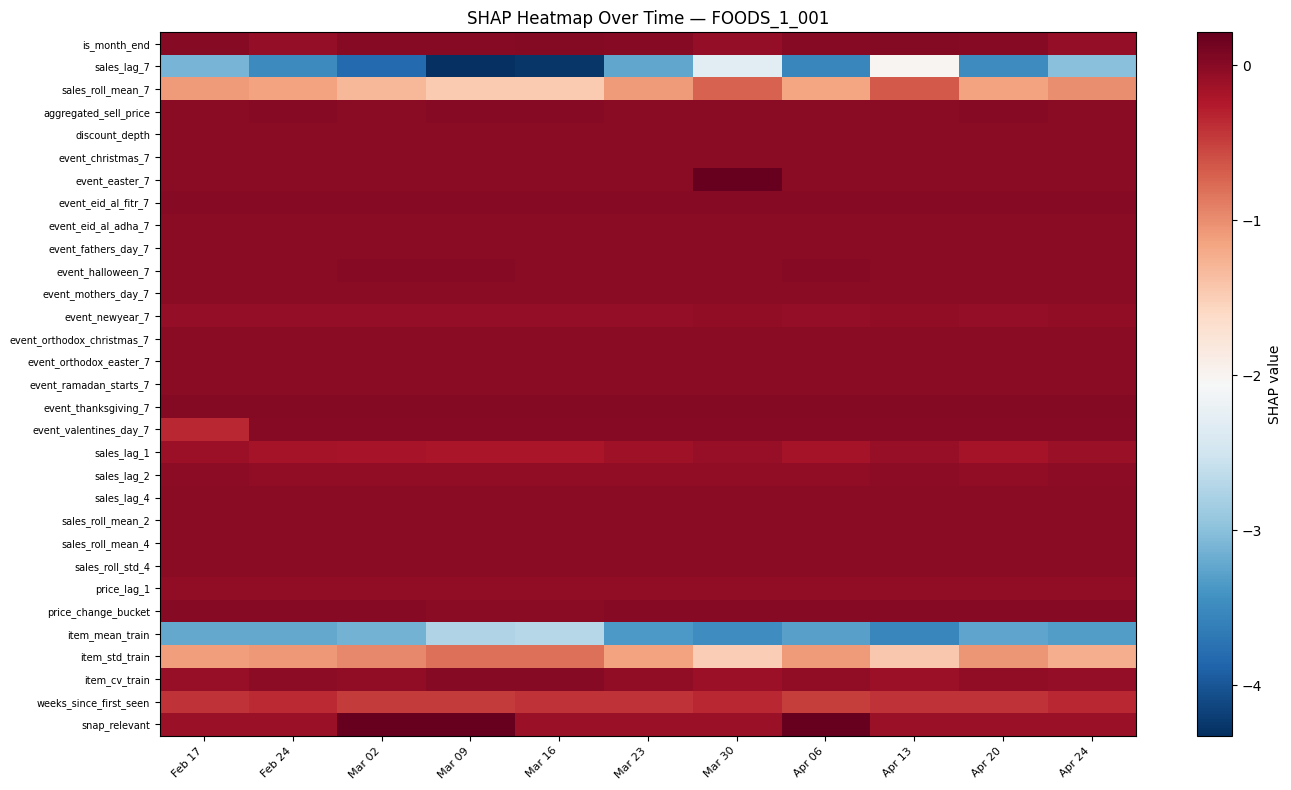

In [7]:
skip = {'date', 'prediction', 'total_shap'}
heat_cols = [c for c in temporal_df.columns if c not in skip]
heat_data = temporal_df[heat_cols].values.T  # (features x dates)

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(heat_data, aspect='auto', cmap='RdBu_r', interpolation='nearest')
plt.colorbar(im, ax=ax, label='SHAP value')
ax.set_yticks(range(len(heat_cols)))
ax.set_yticklabels(heat_cols, fontsize=7)
date_labels = temporal_df['date'].dt.strftime('%b %d').tolist()
step = max(1, len(date_labels) // 8)
ax.set_xticks(range(0, len(date_labels), step))
ax.set_xticklabels(date_labels[::step], rotation=45, ha='right', fontsize=8)
ax.set_title(f'SHAP Heatmap Over Time — {target_sku}')
plt.tight_layout()
plt.show()

## 8) NLG Temporal Explanation

In [8]:
text = generate_temporal_explanation_text(target_sku, pattern_info, top_drivers)
print(text)

=== Temporal Demand Pattern: FOODS_1_001 ===
Pattern detected: STABLE (confidence: 89%)
Description: This SKU shows stable demand — sales remain consistent with little variation across periods.
Mean 7-day forecast: 4.7 units  |  Std dev: 0.5 units

Top features driving temporal SHAP variance (most time-sensitive drivers):
  sales_lag_7                          mean SHAP=-3.328  std=0.682
  item_mean_train                      mean SHAP=-3.203  std=0.250
  sales_roll_mean_7                    mean SHAP=-1.112  std=0.246
  item_std_train                       mean SHAP=-1.109  std=0.212
  snap_relevant                        mean SHAP=-0.013  std=0.129
  event_valentines_day_7               mean SHAP=-0.025  std=0.104
  event_easter_7                       mean SHAP=+0.015  std=0.063
  weeks_since_first_seen               mean SHAP=-0.414  std=0.047

The most time-sensitive driver is 'sales_lag_7' — its SHAP contribution varies the most across dates, making it the primary source of deman

## 9) Compare Patterns Across Multiple SKUs

In [9]:
# Run pattern classification on top 10 SKUs by row count
top_skus = sku_counts.index[:10].tolist()
pattern_rows = []

for sku in top_skus:
    try:
        t_df = compute_temporal_shap(model, X_test, test_df['date'], test_df['item_id'], sku)
        info = classify_demand_pattern(t_df, sku)
        pattern_rows.append(info)
    except Exception as e:
        print(f'  Skipped {sku}: {e}')

pattern_summary = pd.DataFrame(pattern_rows)
print(pattern_summary.to_string(index=False))

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
     sku_id  pattern  confidence  mean_pred  std_pred  trend_slope     cv
FOODS_1_001   stable       0.893       4.71      0.51       0.0716 0.1075
FOODS_1_002 seasonal       0.500       3.00      0.57       0.0208 0.1904
FOODS_1_003   stable       0.969       4.86      0.15       0.0119 0.0312
FOODS_1_004   stable       0.900      21.73      2.18       0.1531 0.1004
FOODS_1_005   stable       0

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
